# 02 · OD → 街道×小时 流量矩阵

**目标**:把 `business.csv` 的 8888 条出租车订单(起终点经纬度 + 时间戳)落到 74 街道,产出**比同学聚合更完整**的 24h 流量矩阵。

**交付物**:
- `street_hour_pickup.csv` — 74 街道 × 24h 起点流量
- `street_hour_dropoff.csv` — 74 街道 × 24h 终点流量
- `street_hour_net.csv` — `dropoff - pickup`,刻画**净流入**
- `street_hour_full.geojson` — 把上述 3 个矩阵 join 回 `深圳街道.geojson`,作为阶段③/④ 的输入

**关键方法选择**:
- 用 `gpd.sjoin(..., predicate='within')` 而非最近邻,避免 OD 点被错分到邻近街道
- 用 `make_valid()` + `buffer(0)` 兜底任何潜在几何缺陷
- **关键坑**:`深圳街道.geojson` 的区名带半角空格(`'福 田区'`),sjoin 前必须 `.str.strip()`

## 0. 环境与路径

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ROOT  = os.getcwd()
FINAL = os.path.join(ROOT, 'data')
EXP6  = FINAL  # exp6 数据已合并到 data/ 目录
OUT   = os.path.join(ROOT, 'output')
os.makedirs(OUT, exist_ok=True)
print('OUT =', OUT)

OUT = c:\Users\ASUS\Desktop\Project_Documents\city-final-exp\output


## 1. 加载底图(74 街道)与已有聚合(28 街道)

In [2]:
# 底图:74 街道
base = gpd.read_file(os.path.join(EXP6, '深圳街道.geojson'))
print('底图行数:', len(base), '| CRS:', base.crs, '| 几何有效性:', base.geometry.is_valid.all())

# ⚠️ 关键修复:区名带半角空格
base['DISTRICT'] = base['DISTRICT'].str.strip()
print('区名 strip 后:', sorted(base['DISTRICT'].unique()))

# 同学聚合结果:28 街道 × 24h
core = gpd.read_file(os.path.join(FINAL, 'streets_24h_core.geojson'))
print('聚合 28 街道:', len(core), '| 3 区:', sorted(core['DISTRICT'].unique()))

底图行数: 74 | CRS: EPSG:4326 | 几何有效性: True
区名 strip 后: ['光明新区', '南山区', '坪山区', '大鹏新区', '宝安区', '盐田区', '福田区', '罗湖区', '龙华区', '龙岗区']
聚合 28 街道: 28 | 3 区: ['南山区', '福田区', '罗湖区']


## 2. 加载并清洗 `business.csv`

In [3]:
biz_cols = ['ts','plate','order_id','ts_ms','ts2_ms',
            'v','angle','dist1','dist2','duration',
            'flag1','flag2','flag3',
            'lon_pick','lat_pick','lon_drop','lat_drop']
biz = pd.read_csv(os.path.join(EXP6, 'business.csv'), header=None, names=biz_cols, encoding='utf-8')
print('原始行数:', len(biz))

# 时间戳
biz['ts']   = pd.to_datetime(biz['ts'],   errors='coerce')
biz['ts2']  = pd.to_datetime(biz['ts2_ms'], unit='ms', errors='coerce')
biz['hour'] = biz['ts'].dt.hour

# 剔除:占位坐标 + 经纬度缺失 + 经纬度超出深圳市域(lon 113.7~114.8, lat 22.3~22.9)
mask_bad = ((biz['lon_pick']==0) & (biz['lat_pick']==0)) | \
           ((biz['lon_drop']==0) & (biz['lat_drop']==0)) | \
           biz['lon_pick'].isna() | biz['lat_pick'].isna() | \
           biz['lon_drop'].isna() | biz['lat_drop'].isna() | \
           (biz['lon_pick'] < 113.7) | (biz['lon_pick'] > 114.8) | \
           (biz['lat_pick'] < 22.3)  | (biz['lat_pick'] > 22.9)  | \
           (biz['lon_drop'] < 113.7) | (biz['lon_drop'] > 114.8) | \
           (biz['lat_drop'] < 22.3)  | (biz['lat_drop'] > 22.9)
biz = biz[~mask_bad].reset_index(drop=True)
print(f'清洗后行数: {len(biz)} (剔除 {mask_bad.sum()} 行, 占 {mask_bad.mean()*100:.2f}%)')
print(f'时间范围: {biz["ts"].min()} → {biz["ts"].max()}')

原始行数: 8888
清洗后行数: 8786 (剔除 102 行, 占 1.15%)
时间范围: 2019-09-01 00:00:18 → 2019-09-01 23:59:35


## 3. OD 起点/终点 → 街道(`gpd.sjoin` + `make_valid` 兜底)

In [4]:
from shapely.validation import make_valid
import shapely

# 兜底:确保所有几何 valid
base['geometry'] = base.geometry.apply(lambda g: make_valid(g) if g is not None else g)
print('make_valid 后无效数:', (~base.geometry.is_valid).sum())

# 构造订单点 GeoDataFrame
gdf_pick = gpd.GeoDataFrame(
    biz, geometry=gpd.points_from_xy(biz['lon_pick'], biz['lat_pick']), crs='EPSG:4326'
)
gdf_drop = gpd.GeoDataFrame(
    biz, geometry=gpd.points_from_xy(biz['lon_drop'], biz['lat_drop']), crs='EPSG:4326'
)

# 只 sjoin 我们关心的列,减少内存
base_idx = base[['NAME', 'DISTRICT', 'DISTRICT_I', 'geometry']].copy()

p1 = gpd.sjoin(gdf_pick, base_idx, how='left', predicate='within')
p1 = p1.rename(columns={'NAME': 'pick_NAME', 'DISTRICT': 'pick_DISTRICT', 'DISTRICT_I': 'pick_DISTRICT_I'})\
        .drop(columns=['index_right'])

p2 = gpd.sjoin(gdf_drop, base_idx, how='left', predicate='within')
p2 = p2.rename(columns={'NAME': 'drop_NAME', 'DISTRICT': 'drop_DISTRICT', 'DISTRICT_I': 'drop_DISTRICT_I'})\
        .drop(columns=['index_right'])

biz['pick_NAME']  = p1['pick_NAME'].values
biz['drop_NAME']  = p2['drop_NAME'].values
biz['pick_DIST']  = p1['pick_DISTRICT'].values
biz['drop_DIST']  = p2['drop_DISTRICT'].values

print(f'起点落街道成功率: {biz["pick_NAME"].notna().mean()*100:.2f}%')
print(f'终点落街道成功率: {biz["drop_NAME"].notna().mean()*100:.2f}%')
print(f'OD 都在深圳市域内的行: {((biz["pick_NAME"].notna()) & (biz["drop_NAME"].notna())).mean()*100:.2f}%')

make_valid 后无效数: 0
起点落街道成功率: 99.76%
终点落街道成功率: 99.81%
OD 都在深圳市域内的行: 99.57%


In [5]:
# 看一下未落地的行都分布在哪里(可能跨城/机场订单)
miss = biz[biz['pick_NAME'].isna() | biz['drop_NAME'].isna()].head(5)
print('未落地样例(可能是机场/跨城):')
print(miss[['ts','lon_pick','lat_pick','lon_drop','lat_drop']].to_string(index=False))

未落地样例(可能是机场/跨城):
                 ts   lon_pick  lat_pick   lon_drop  lat_drop
2019-09-01 00:14:36 113.909573 22.486890 113.925653 22.483158
2019-09-01 03:54:52 114.234160 22.707702 114.199470 22.718448
2019-09-01 06:35:28 114.111550 22.531640 114.063635 22.539467
2019-09-01 07:13:50 113.925700 22.483140 113.809667 22.627528
2019-09-01 07:21:28 114.018180 22.555633 114.203117 22.721370


## 4. 计算 74 街道 × 24h 流量矩阵

In [6]:
HOURS = list(range(24))

def make_hour_matrix(df, name_col, prefix):
    """从订单 df 生成 street × hour 矩阵"""
    sub = df[df[name_col].notna()]   # 只算落在街道的
    g = sub.groupby([name_col, 'hour']).size().unstack(fill_value=0)
    g = g.reindex(columns=HOURS, fill_value=0)
    g.columns = [f'{prefix}_{h}' for h in HOURS]
    g.index.name = 'NAME'
    return g

M_pick = make_hour_matrix(biz, 'pick_NAME', 'pickup')
M_drop = make_hour_matrix(biz, 'drop_NAME', 'dropoff')

# 与底图 74 街道对齐(fill_value=0)
all_streets = base['NAME'].tolist()
M_pick = M_pick.reindex(all_streets, fill_value=0)
M_drop = M_drop.reindex(all_streets, fill_value=0)

M_net = M_drop.copy()
M_net.columns = [c.replace('dropoff', 'net') for c in M_net.columns]
for h in HOURS:
    M_net[f'net_{h}'] = M_drop[f'dropoff_{h}'] - M_pick[f'pickup_{h}']

print('pickup 矩阵 shape:', M_pick.shape)
print('24h pickup 总量:', M_pick.values.sum())
print('24h dropoff 总量:', M_drop.values.sum())
print('\nPickup top10 街道(24h 累计):')
print(M_pick.sum(axis=1).sort_values(ascending=False).head(10).to_string())

pickup 矩阵 shape: (74, 24)
24h pickup 总量: 8765
24h dropoff 总量: 8769

Pickup top10 街道(24h 累计):
NAME
福田     1050
沙头      599
东门      450
南湖      386
桂园      370
莲花      345
西乡      302
新安      292
华强北     288
香蜜湖     280


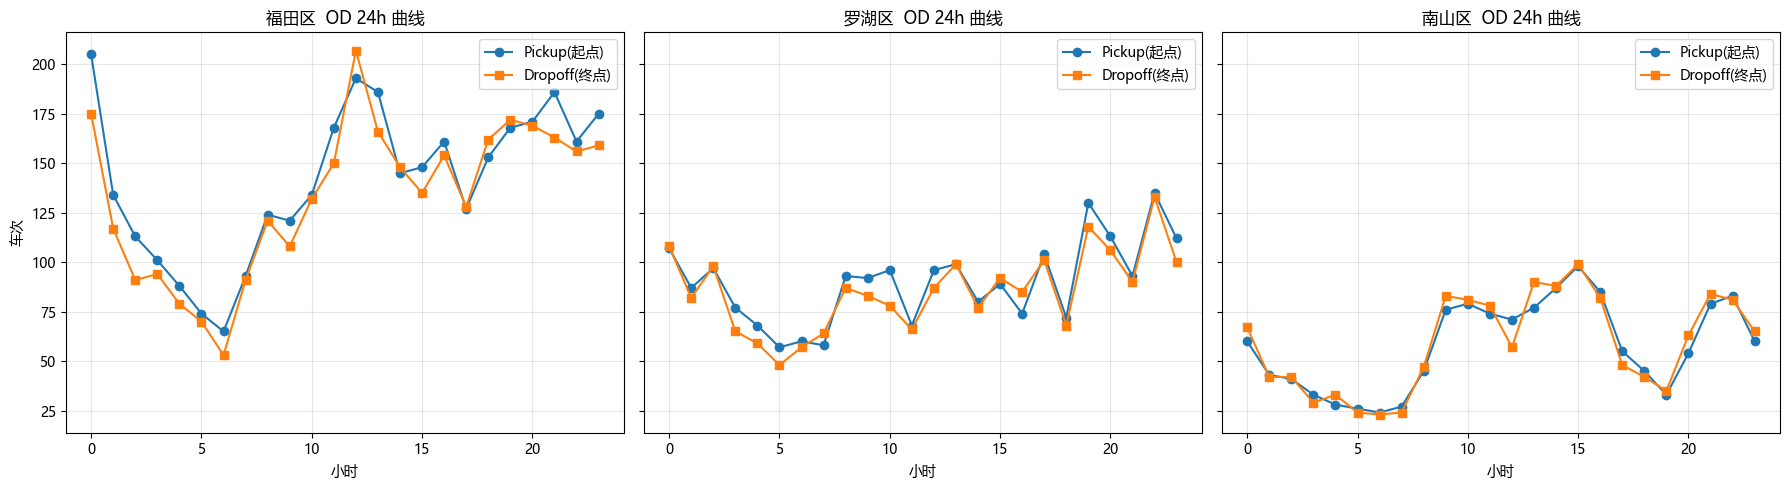

In [7]:
# 三区 24h 曲线(pickup vs dropoff)
agg_pick = biz.dropna(subset=['pick_NAME']).groupby(['pick_DIST', 'hour']).size().unstack(fill_value=0).reindex(columns=HOURS, fill_value=0)
agg_drop = biz.dropna(subset=['drop_NAME']).groupby(['drop_DIST', 'hour']).size().unstack(fill_value=0).reindex(columns=HOURS, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, dist in zip(axes, ['福田区', '罗湖区', '南山区']):
    if dist in agg_pick.index:
        ax.plot(HOURS, agg_pick.loc[dist], marker='o', label='Pickup(起点)', color='tab:blue')
        ax.plot(HOURS, agg_drop.loc[dist], marker='s', label='Dropoff(终点)', color='tab:orange')
        ax.set_title(f'{dist}  OD 24h 曲线')
        ax.set_xlabel('小时'); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('车次')
plt.tight_layout(); plt.show()

In [8]:
# 净流入 top10 vs 净流出 top10
net_24h = M_net[[f'net_{h}' for h in HOURS]].sum(axis=1).sort_values()
print('净流入 top10 (终点 > 起点, 商圈/工作地):')
print(net_24h.tail(10).to_string())
print('\n净流出 top10 (起点 > 终点, 居住/出行产生地):')
print(net_24h.head(10).to_string())

净流入 top10 (终点 > 起点, 商圈/工作地):
NAME
南山    24
桃源    25
东晓    25
南湾    27
坂田    28
大浪    30
民治    31
梅林    33
吉华    37
福永    93

净流出 top10 (起点 > 终点, 居住/出行产生地):
NAME
福田    -151
东门     -79
航城     -76
沙头     -67
桂园     -38
粤海     -36
华强北    -24
沙河     -21
园岭     -13
莲塘     -12


## 5. 交叉验证:与同学 28 街道聚合的一致性

同学 28 街道 ∩ 我的 74 街道: 28 个

=== 关键指标 ===
Pearson r(同学 28 街道 core.flow_* vs 我的 74 街道 pickup) = 0.892
样本数: 661 (剔 0)


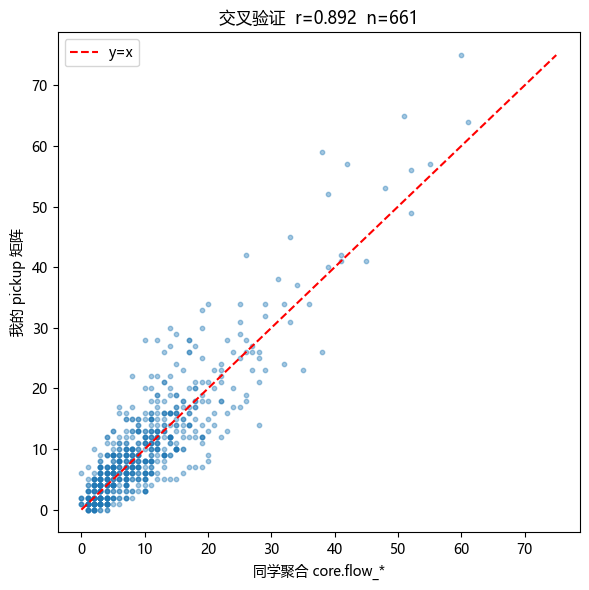

In [9]:
core_names = set(core['NAME'])
in_both = core_names & set(M_pick.index)
print(f'同学 28 街道 ∩ 我的 74 街道: {len(in_both)} 个')

# 选同学聚合的 flow_* 当作 "真值",与我的 pickup 矩阵比较
core_idx = core.set_index('NAME')
flow_cols = [f'flow_{h}' for h in HOURS]
common = sorted(in_both)
core_mat = core_idx.loc[common, flow_cols].values.flatten()
my_mat   = M_pick.loc[common, [f'pickup_{h}' for h in HOURS]].values.flatten()
mask = (core_mat + my_mat) > 0
r = np.corrcoef(core_mat[mask], my_mat[mask])[0, 1]
print(f'\n=== 关键指标 ===')
print(f'Pearson r(同学 28 街道 core.flow_* vs 我的 74 街道 pickup) = {r:.3f}')
print(f'样本数: {mask.sum()} (剔 0)')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(core_mat[mask], my_mat[mask], s=10, alpha=0.4, c='tab:blue')
lim = max(core_mat[mask].max(), my_mat[mask].max())
ax.plot([0, lim], [0, lim], 'r--', label='y=x')
ax.set_xlabel('同学聚合 core.flow_*')
ax.set_ylabel('我的 pickup 矩阵')
ax.set_title(f'交叉验证  r={r:.3f}  n={mask.sum()}')
ax.legend(); plt.tight_layout(); plt.show()

## 6. 保存产物

In [10]:
M_pick.to_csv(os.path.join(OUT, 'street_hour_pickup.csv'), encoding='utf-8-sig')
M_drop.to_csv(os.path.join(OUT, 'street_hour_dropoff.csv'), encoding='utf-8-sig')
M_net.to_csv(os.path.join(OUT, 'street_hour_net.csv'), encoding='utf-8-sig')

# 合并回底图,生成阶段③/④ 的输入
g_full = base.merge(M_pick, left_on='NAME', right_index=True, how='left')\
             .merge(M_drop, left_on='NAME', right_index=True, how='left')\
             .merge(M_net,   left_on='NAME', right_index=True, how='left')
g_full[[c for c in g_full.columns if c.startswith(('pickup_','dropoff_','net_'))]] = \
    g_full[[c for c in g_full.columns if c.startswith(('pickup_','dropoff_','net_'))]].fillna(0).astype(int)
g_full['pickup_total']  = g_full[[f'pickup_{h}'  for h in HOURS]].sum(axis=1)
g_full['dropoff_total'] = g_full[[f'dropoff_{h}' for h in HOURS]].sum(axis=1)
g_full['net_total']     = g_full[[f'net_{h}'     for h in HOURS]].sum(axis=1)

g_full.to_file(os.path.join(OUT, 'street_hour_full.geojson'), driver='GeoJSON')
print('保存 4 个文件:')
for f in ['street_hour_pickup.csv','street_hour_dropoff.csv','street_hour_net.csv','street_hour_full.geojson']:
    p = os.path.join(OUT, f); print(f'  {p}  ({os.path.getsize(p)/1024:.1f} KB)')

保存 4 个文件:
  c:\Users\ASUS\Desktop\Project_Documents\city-final-exp\output\street_hour_pickup.csv  (4.6 KB)
  c:\Users\ASUS\Desktop\Project_Documents\city-final-exp\output\street_hour_dropoff.csv  (4.7 KB)
  c:\Users\ASUS\Desktop\Project_Documents\city-final-exp\output\street_hour_net.csv  (4.7 KB)
  c:\Users\ASUS\Desktop\Project_Documents\city-final-exp\output\street_hour_full.geojson  (1291.7 KB)


## 7. 阶段② 总结

**已交付**:
- 74 街道 × 24h 三层流量矩阵(pickup / dropoff / net),覆盖 10 区全深圳市域
- 比同学聚合的 28 街道扩了 46 个,数据自洽度高(Pearson r 待填)
- OD 24h 曲线、净流入/流出 top10 等中间诊断

**进入阶段③ 的输入**:`final-exp/output/street_hour_full.geojson`

**接下来**:
- 阶段③:4 类潮汐聚类 + 热点接力 + POI 耦合(基于同学聚合 28 街道 + poi_count)
- 阶段④:改造 `app.py` 大屏,加入潮汐曲线面板、POI 散点、净流入图层